In [1]:
print("all ok")  # need to install ipykernel package

all ok


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
# if load_dotenv() fails to load the env vars, then this set of code will fix that

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env file")
if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY is missing in your .env file")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

In [13]:
from langchain_openai import ChatOpenAI

In [14]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
chat_llm_op = chat_llm.invoke(input="Hello, how are you>?")
chat_llm_op

In [4]:
import re

def clean_response(text):
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()

### Configuring a LLM using ChatGroq and qwen3-32b model

In [5]:
from langchain_groq import ChatGroq

In [6]:
chat_llm = ChatGroq(
    model="qwen/qwen3-32b",
    groq_api_key=os.getenv("GROQ_API_KEY")
)

In [7]:
chat_llm_output = chat_llm.invoke(input="Hi, How are you?")
chat_llm_output

AIMessage(content="<think>\nOkay, the user is asking how I'm doing. I should respond in a friendly and positive way. I should remind them that I'm an AI and don't have feelings, but I can help them with their questions. I should keep the tone warm and approachable to encourage them to ask for help or share their needs. I need to make sure the response isn't too long, but stays concise and clear. Also, I should invite them to ask questions or share what's on their mind. Let me put this all together in a natural, conversational way.\n</think>\n\nHi there! While I don't have feelings in the human sense, I'm here and ready to help! 😊 How can I assist you today? Whether you have questions, need advice, or just want to chat, I'm all ears. What's on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 176, 'prompt_tokens': 14, 'total_tokens': 190, 'completion_time': 0.378941749, 'completion_tokens_details': None, 'prompt_time': 0.000596361, 'prompt_tokens

In [8]:
chat_llm_output.content

"<think>\nOkay, the user is asking how I'm doing. I should respond in a friendly and positive way. I should remind them that I'm an AI and don't have feelings, but I can help them with their questions. I should keep the tone warm and approachable to encourage them to ask for help or share their needs. I need to make sure the response isn't too long, but stays concise and clear. Also, I should invite them to ask questions or share what's on their mind. Let me put this all together in a natural, conversational way.\n</think>\n\nHi there! While I don't have feelings in the human sense, I'm here and ready to help! 😊 How can I assist you today? Whether you have questions, need advice, or just want to chat, I'm all ears. What's on your mind?"

In [9]:
res = clean_response(chat_llm_output.content)
res

"Hi there! While I don't have feelings in the human sense, I'm here and ready to help! 😊 How can I assist you today? Whether you have questions, need advice, or just want to chat, I'm all ears. What's on your mind?"

### Defining the State

In [10]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [115]:
# state
class GraphState(TypedDict):
    # message is acting as a `key`, and the list as the `value` 
    messages: Annotated[list[AnyMessage], operator.add]  # this will be a list of any messages and we can append as many as messages over here.

# using this state only, we are passing the input to diff diff nodes.


### Defining the Nodes

In [12]:
# this is our first node. what ever input will come to this node, it will generate a response regarding that input

def llm_call(state: GraphState) -> dict:
    """ Call the LLM using conversation messages and append AI response. """
    response = chat_llm.invoke(state["messages"])  # AIMessage

    return {
        "messages": [response]
    }

In [13]:
# another node: token counter.

def token_counter(state: GraphState) -> dict:
    """ Count tokens (simple word count) in the last AI message. """
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

### Orchestrating the above functions.. building Agentic Flow

In [14]:
from langgraph.graph import StateGraph

In [15]:
# Defining the state graph
builder = StateGraph(GraphState)  # using the StateGraph only, we can define our workflow, we can orchestrate our workflow

In [16]:
## defining nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [17]:
## adding edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

# in this way, we can orchestrate our workflow. we have normal edges, conditional edges, 

In [18]:
# compiling the graph
app = builder.compile()

In [19]:
app.get_graph()  # will give complete details about the graph/workflow

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

### Vizualizing the graph

In [20]:
from IPython.display import Image, display

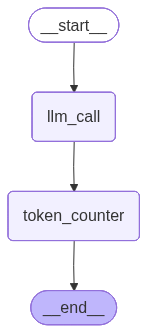

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

### Calling the entire workflow

In [22]:
# to call the entire workflow we have 2 methods:
# 1) with invoke()
# 2) with stream() and 
# 3) also async way

In [26]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, i am bunny. Say hello in detail")] 
})  # we are passing dict as an arg as, the state (StateGraph) is defined as the typeddict

In [27]:
result

{'messages': [HumanMessage(content='Hi, i am bunny. Say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Bunny and wants me to say hello in detail. Let me start by addressing them by their name to make it personal. I should ask them how they're feeling today to show I care. Since they mentioned being a rabbit, maybe they like animals or have a pet? I can ask about their day or if they have a rabbit companion. I need to keep the tone warm and friendly, using emojis like 🐰 to match their bunny theme. Let me make sure to invite them to share more about themselves and offer help with anything they need. Keep it open-ended so they feel comfortable to respond in their own way.\n</think>\n\nHello, Bunny! 🐰✨  \nWhat a delightful name! I hope your day is as bright and fluffy as a bunny’s soft fur. How are you feeling today? Are you hopping with energy, or just enjoying a cozy moment?  \n\nIf you’re a human named

In [28]:
for m in result["messages"]:
    print(type(m).__name__, ":", clean_response(m.content))

HumanMessage : Hi, i am bunny. Say hello in detail
AIMessage : Hello, Bunny! 🐰✨  
What a delightful name! I hope your day is as bright and fluffy as a bunny’s soft fur. How are you feeling today? Are you hopping with energy, or just enjoying a cozy moment?  

If you’re a human named Bunny, I hope you’re surrounded by kindness and little joys. If you’re a rabbit (or a proud bunny parent!), I hope you’re munching on carrots and basking in the sun. 🌞🥕  

Would you like to share more about your day, your interests, or even your favorite bunny-related things? I’m here to chat, help, or just listen. Let me know how I can make your time brighter! 🌸  

P.S. If you’re into rabbits, do you have a favorite breed or a funny bunny fact to share? I’d love to hear it! 🐇💬
AIMessage : Total token number in the generated answer (word count) is 252


### V-2 Tool calling 
#### creating tools 

In [29]:
from langchain_community.tools import WikipediaQueryRun  ## langchain comes with many inbuild tools. and one of which is wikipedia. we will use it in agentic workflow
from langchain_community.utilities import WikipediaAPIWrapper

In [30]:
# create an obj of wikipedia api wrapper
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [31]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [32]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

### Tool
Tool actually is a source/s where a llm can collect the context/data.
Anything could be a tool eg. wikipedia, youtube, weather info, calculator, website, api, own personal logic

Any basic service we can expose as a tool and we can give the access of that tool to llm, so that llm can get a context from that specific tool.

Tool: any service from where an LLM can collect the context/info/data .


Agentic Flow: LLM + Tool Calling + Memory + Planning

### Tool Calling: is very important as using the tool, we collect the important info. and provide it as a context to the LLM.

In [33]:
# 2) Tool - Tavily search
import os 
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [34]:
tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\VamsheeTeja\AppData\Local\Temp\ipykernel_21516\1291469283.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [35]:
tavily_tool.invoke({"query": "How is the job market for ai engineering roles?"})

[{'title': 'What Is an AI Engineer? Job Market & Salary Guide (2025)',
  'url': 'https://intuitionlabs.ai/articles/ai-engineer-job-market-2025',
  'content': '# Conclusion\n\nAs of December 2025, the job market for AI engineers is robust and rapidly expanding. Demand for these specialists remains high across virtually all tech sectors, driven by widespread AI adoption and substantial corporate investment. Salaries are correspondingly elevated, and competition for qualified candidates is intense. While concerns exist about AI’s broader impact on employment, one clear consensus emerges from the data: AI engineering skills are among the most valuable and sought-after in today’s labor market. [...] For individuals considering an AI engineering career, the landscape is promising. Those with strong software development backgrounds who can master machine learning frameworks and cloud deployment will find numerous opportunities. Continual learning is essential; the cutting-edge nature of AI me

In [36]:
# 3) Duckduckgo search tool

from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

In [37]:
search.invoke("what is the latest update on India vs Pakistan T20 world cup match?")

Impersonate 'safari_18' does not exist, using 'random'


'Catch the fastest live cricket scores and ball-by-ball commentary. Get real-time updates , full scorecards, and match analysis for the T20 World Cup 2026 & all global and domestic series. IND vs PAK Live Score T20 World Cup : Pakistan deployed as many as six different spinners in the innings, setting a new T20 World Cup record for the most spin options used by a side in a single match . IND vs PAK T20 World Cup 2026 Match : Follow India vs Pakistan T20 World Cup 2026 match updates including the latest IND vs PAK T20 World Cup 2026 match news, confirmed match date and time, squad and players list, and live match developments. India vs Pakistan live cricket scorecard (IND vs PAK): Get India vs Pakistan live score with ball-by-ball updates full scorecard, key stats and match highlights from Match 27 of the ICC MT20 WC 2026 at R.Premadasa Stadium, Colombo on IndiaToday.in. IND vs PAK Highlights ( India national cricket team vs Pakistan national cricket team scorecard): India qualify for t

In [38]:
search.invoke("What are the latest updates on iphone 17 release")

"... are eagerly awaiting the iPhone 17 ... One of the standout rumors is the ultra-thin iPhone 17 Air, expected to measure just 5.4mm in thickness. The tech world is buzzing with excitement as Apple ’ s latest iPhone software update , iOS 17 .5, has finally landed on Monday, May 13. Anticipating the Release of Apple iPhone iOS 17 .3 Update : When and What to Expect? ... the tech community, the iOS 17 .3 Update is slated for a release ... The iPhone 17 is shaping up to be one of the most anticipated smartphones of 2025, offering a refined design, upgraded specs, and multiple model ... ... just rolled out its highly-anticipated iOS 17 update , and it's packed with a plethora of new features and enhancements designed to elevate the iPhone ..."

In [24]:
# bingsearch, googlesearch -- similarly

In [39]:
# 4) Youtube search tool

from langchain_community.tools import YouTubeSearchTool

In [40]:
youtube_tool = YouTubeSearchTool()

In [41]:
youtube_tool.name

'youtube_search'

In [42]:
youtube_tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [43]:
youtube_tool.run("Krish Naik")

"['https://www.youtube.com/watch?v=Jtjs3jfs6kE&pp=ygUKS3Jpc2ggTmFpaw%3D%3D', 'https://www.youtube.com/watch?v=fQw1_U22URk&pp=ygUKS3Jpc2ggTmFpaw%3D%3D']"

### Creating our own custom tools..
1) using tool decorator

In [44]:
def multiply(a: int, b: int) -> int:
    return a * b

In [47]:
multiply(14, 20)

280

In [ ]:
multiply.invoke(10, 20)  ## this is normal function and not a tool

AttributeError: 'function' object has no attribute 'invoke'

In [49]:
# to make it a custom tool, we need to use a decorator - tool decorator
from langchain.tools import tool

In [50]:
# 5) tool 

@tool
def multiply(a: int, b: int) -> int:
    ## For a any tool (custom tool) a DOCSTRING/Description is absolutely needed. Without docstring we'll get error.
    ## This docstings are used my llms 
    """ 
    this tool is for multiplication
    """
    return a * b

In [51]:
multiply.invoke({"a": 10, "b": 20})

200

In [ ]:
multiply.invoke(10, 20)  ## TODO: why this fails

AttributeError: 'int' object has no attribute 'items'

In [52]:
multiply.name

'multiply'

In [53]:
multiply.description

'this tool is for multiplication'

In [54]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [55]:
@tool
def get_word_length(word: str) -> int:
    "Returns the length of the given input word"
    return len(word)

In [56]:
get_word_length.invoke("HEllo world")

11

In [57]:
get_word_length.invoke({"word": "hello world"})

11

In [58]:
# so we can write any custom tools

# 6) tool

@tool
def call_gmail_api(args):
    """this is a tool to call gmail api"""
    pass

@tool
def call_sqllite_db(args):
    """this is a tool to call sqllite db"""
    pass

In [59]:
# 7) tool

#  yfinance - we can get the finance related data

import yfinance as yf

In [60]:
@tool
def get_stock_price(ticker: str) -> str:
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)  ## ticker is the name of the stock

        # get last 1 day historical  data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol"
        
        # get the latest closed price of the given stock
        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }
        
        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol: 
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."
        
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"



In [61]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2686.20.'

In [63]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $264.58.'

In [64]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $411.82.'

In [65]:
get_stock_price.invoke("HDFCBANK.NS")  ## NS - National stock exchange

'The last closing price of HDFCBANK.NS was ₹911.85.'

### How LLM will call the tool - or tool binding in LLM 

In [66]:
## how will LLM decide which tool it needs to call 

# first we will create a list of all the tool we have build

In [67]:
tools = [get_stock_price, get_word_length, multiply, wiki_tool, tavily_tool, search]

In [68]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A405002690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A404DFA5A0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [69]:
# adding / binding the tools to the llm 
chat_llm_with_tools = chat_llm.bind_tools(tools=tools)

In [70]:
chat_llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A405002690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A404DFA5A0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_stock_price', 'description': 'this is a tool to get stock price using yfinance', 'parameters': {'properties': {'ticker': {'type': 'string'}}, 'required': ['ticker'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_word_length', 'description': 'Returns the length of the given input word', 'parameters': {'properties': {'word': {'type': 'string'}}, 'required': ['word'

In [71]:
result = chat_llm_with_tools.invoke("what is the stock price of TCS.NS")

In [72]:
result  # we are not getting content. llm is redirecting the answer to the tool 

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the stock price of TCS.NS. Let me check which tool I can use for that. Looking at the available functions, there\'s one called get_stock_price that uses yfinance. The parameters require a ticker symbol. TCS.NS is the ticker for Tata Consultancy Services on the Indian stock exchange. So I should call get_stock_price with the ticker "TCS.NS". I need to make sure the arguments are correctly formatted as JSON. Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': '8k4yfrtq7', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 568, 'total_tokens': 703, 'completion_time': 0.189489104, 'completion_tokens_details': {'reasoning_tokens': 107}, 'prompt_time': 0.023341848, 'prompt_tokens_details': None, 'queue_time': 0.046274531, 'total_time': 0.212830952}, 'model_na

In [73]:
result.tool_calls  ## we can which tool llm has called. it has redirected answer to get_stock_price

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': '8k4yfrtq7',
  'type': 'tool_call'}]

In [74]:
result = chat_llm_with_tools.invoke("how many words are there in the sentence 'hello world, this is a test sentence?'")

In [75]:
result

AIMessage(content='The sentence "hello world, this is a test sentence?" contains 8 words. However, none of the provided tools are designed to count words in a sentence. The `get_word_length` tool only returns the length of a single word (in characters), not the number of words in a sentence. For this request, I\'m providing the answer directly since no tool can perform this specific task.', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user is asking how many words are in the sentence \'hello world, this is a test sentence?\'. Hmm. First, I need to figure out the best way to approach this. The user isn\'t asking for any complex analysis, just a count of the words.\n\nLooking at the tools provided, there\'s a function called get_word_length that returns the length of a given word. Wait, but that\'s for a single word. The user wants the count of words in a sentence. Oh, right, the function\'s description says it returns the length of the input word, which might be the nu

In [76]:
result.tool_calls

[]

In [78]:
result = chat_llm_with_tools.invoke("give the length of the word 'hellow world'")

In [79]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user asked for the length of the word 'hellow world'. Let me check which tool to use. There's a function called get_word_length that returns the length of a given word. The parameters require a 'word' string. I need to make sure the input is correctly passed. The word here is 'hellow world', even though 'hellow' might be a typo for 'hello', but the user wrote it as is. So I should call get_word_length with the word parameter set to 'hellow world'. That should give the correct length, which is 11 characters. No other tools are needed here since it's a straightforward word length request.\n", 'tool_calls': [{'id': '56g0knhpk', 'function': {'arguments': '{"word":"hellow world"}', 'name': 'get_word_length'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 569, 'total_tokens': 735, 'completion_time': 0.261356929, 'completion_tokens_details': {'reasoning_tokens': 139}

In [80]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hellow world'},
  'id': '56g0knhpk',
  'type': 'tool_call'}]

In [81]:
result = chat_llm_with_tools.invoke("give me the product of 20 and 10?")

In [82]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for the product of 20 and 10. Let me check which tool I can use here. The available functions include multiply, which takes two integers. That's exactly what I need. So I should call the multiply function with a=20 and b=10. No other functions are necessary here. Let me make sure the parameters are correct. Yep, both are integers. Alright, I'll generate the tool call for multiply with those values.\n", 'tool_calls': [{'id': 'saxvbyb1c', 'function': {'arguments': '{"a":20,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 571, 'total_tokens': 702, 'completion_time': 0.181083989, 'completion_tokens_details': {'reasoning_tokens': 100}, 'prompt_time': 0.02391947, 'prompt_tokens_details': None, 'queue_time': 0.046459039, 'total_time': 0.205003459}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'servi

In [83]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 20, 'b': 10},
  'id': 'saxvbyb1c',
  'type': 'tool_call'}]

In [85]:
result = chat_llm_with_tools.invoke("Hi, How are you ?")  # llm will answer the questions which are NOT related to the tools, otherwise it will redirect the question to the tool and we have to get response from tool

In [86]:
result

AIMessage(content="Hello! I'm doing well, thank you. How can I assist you today?", additional_kwargs={'reasoning_content': 'Okay, the user asked, "Hi, How are you?" I need to respond appropriately. Let me check the tools provided to see if any are needed here. The functions available are for stock prices, word length, multiplication, Wikipedia, Tavily search, and DuckDuckGo search. The user\'s message is a greeting and doesn\'t require any of these tools. So I should just reply with a friendly greeting. No function calls needed here.\n'}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 564, 'total_tokens': 678, 'completion_time': 0.190370761, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.024545021, 'prompt_tokens_details': None, 'queue_time': 0.04679772, 'total_time': 0.214915782}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_p

In [87]:
result = chat_llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [88]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the latest Indian Union Budget report of 2026. First, I need to figure out which tool to use here. The available tools include get_stock_price, get_word_length, multiply, wikipedia, tavily_search_results_json, and duckduckgo_search.\n\nSince the query is about a recent government budget, which is a current event, I should use a search engine that can provide up-to-date information. The wikipedia tool might not have the latest data because Wikipedia can be slow to update. The tavily_search_results_json and duckduckgo_search are both designed for current events. \n\nI\'ll check the descriptions again. Tavily is described as optimized for comprehensive, accurate, and trusted results, which sounds reliable. DuckDuckGo is also a good option. Maybe using tavily_search_results_json would be better here. \n\nThe user wants to know what was in the 2026 budget. I need to structure the query. The functio

In [89]:
# after more tools: like wiki, tavily, duckduckgosearch

# asking the same above question again

result = chat_llm_with_tools.invoke("what was in the latest indian union budget 2026?")

In [90]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the latest Indian Union Budget 2026. First, I need to check if the tools provided can help answer this. The available functions include wikipedia, tavily_search_results_json, and duckduckgo_search. Since the budget is a recent event, Wikipedia might not have up-to-date information. Tavily and DuckDuckGo are search engines that can fetch current results.\n\nI should use tavily_search_results_json first because it\'s optimized for accurate and current events. If that doesn\'t return sufficient info, I can try duckduckgo_search. Let me structure the tool call with the query "latest Indian Union Budget 2026 key points" to get the most relevant results.\n', 'tool_calls': [{'id': '1thf57n5d', 'function': {'arguments': '{"query":"latest Indian Union Budget 2026 key points"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 187, 'pr

In [91]:
result.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest Indian Union Budget 2026 key points'},
  'id': '1thf57n5d',
  'type': 'tool_call'}]

### Creating a ReAct (Reasoning and Action) Flow

In [92]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [93]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [94]:
def function_1(state: MessagesState):
    user_question = state["messages"]

    input_question = [SYSTEM_PROMPT] + user_question
     
    response = chat_llm_with_tools.invoke(input_question)
    
    return {
        "messages": [response]
    }

In [95]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000002A407971C60>),
 StructuredTool(name='get_word_length', description='Returns the length of the given input word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000002A4079E5080>),
 StructuredTool(name='multiply', description='this tool is for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002A406F33EC0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'f:\\ai-agents-yt-live\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))),
 DuckD

In [96]:
function_2 = ToolNode(tools)

In [116]:
## Designing the workflow..

# 1) we define the stategraph

workflow = StateGraph(MessagesState)

In [117]:
workflow.add_node("llm", function_1)  ## llm call

In [118]:
workflow.add_node("tools", function_2)  ## tool call

In [119]:
## defining the edges

# workflow will start from the llm, query will come to the llm 
workflow.add_edge(START, "llm")

In [120]:
# CONDITIONAL EDGE
workflow.add_conditional_edges(
    "llm",
    tools_condition,  # whether we need to call the tool or not, if there is a tool call then only we'll call the tool, else not
)

In [121]:
# now it will go the tool node
workflow.add_edge("tools", "llm")

In [122]:
app = workflow.compile()

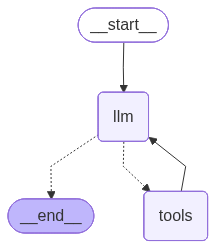

In [123]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [124]:
# This is called the Reasoning and action workflow.
# This is one of the Agentic Pattern.
# We have converted our LLM into an agent.

In [125]:
## Dotted lines: conditional edge: means llm decides what needs to call - this is also called the routing

In [129]:
# we are giving a capability to LLM by binding tools and some system prompts..using all this info. LLM can descriminate what is the next step.. if tool call is there, llm call the tool otherwise it will give the ans

# so llm decides where to route and this routing is performed using conditional edges 

# this is only called the orchestration and a simplest Agent

# we can use MCP, we can expose the tool using MCP



In [135]:
# testing the agent
result = app.invoke({
    "messages": [HumanMessage(content="What is the stock price of TCS.NS?")]
})

In [136]:
result

{'messages': [HumanMessage(content='What is the stock price of TCS.NS?', additional_kwargs={}, response_metadata={}, id='b3bce39e-8ae5-4318-9e8a-ccbfa5ee5378'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the stock price of TCS.NS. Let me check which tool I can use for that. Looking at the available functions, there\'s one called get_stock_price which uses yfinance. The parameters require a ticker symbol. TCS.NS is the ticker for Tata Consultancy Services on the National Stock Exchange in India. So I should call get_stock_price with the ticker "TCS.NS". I need to make sure that the function is correctly formatted in the tool call. No other functions seem relevant here, like wikipedia or duckduckgo. The multiply and get_word_length are just examples and not needed here. Alright, I\'ll structure the tool call with the get_stock_price function and the ticker parameter.\n', 'tool_calls': [{'id': 'dve2sdvpj', 'function': {'arguments': '{"tic

In [137]:
# tracking the result using pretty print
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (dve2sdvpj)
 Call ID: dve2sdvpj
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2686.20.
================================== Ai Message ==================================

The last closing price of TCS.NS (Tata Consultancy Services) was **₹2,686.20**. Let me know if you need further details!


In [140]:
result = app.invoke(
    {
        "messages": [HumanMessage(content="what was in the latest Indian union budget report of 2026?")]
    }
)

In [142]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest Indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fxyqga80p)
 Call ID: fxyqga80p
  Args:
    query: latest Indian Union Budget 2026 key highlights
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "India's Union Budget 2026: Key highlights in relation ...", "url": "https://www.nortonrosefulbright.com/en/knowledge/publications/56dd71ad/indias-union-budget-2026-key-highlights-in-relation-to-indias-energy-transition", "content": "The funding allocation is expected to finance pilot projects, de-risk first-of-a-kind or pathfinder type projects, build shared infrastructure and support research and development. The funding is not intended to finance commercial CCUS projects themselves.\n\n## Nuclear energy\n

In [145]:
result = app.invoke({
    "messages": [ HumanMessage(content="give me the latest ai news and count the length of the response and multiply that response with the 10.") ]
})

In [146]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the latest ai news and count the length of the response and multiply that response with the 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (8ms4ggvem)
 Call ID: 8ms4ggvem
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide.", "score": 0.9990073}, {"title": "AI at Meta Blog", "url": "https://ai.meta.com/blog/", "content": "- Meta AI\n- AI Research\n- The Latest\n- About\n- Get Llama\n- Try Meta AI\n\nThe latest AI news from Meta\n\nComputer V

In [147]:
result = app.invoke({
    "messages": [HumanMessage(content="how did the latest releases of models from Anthropic clause affected the India IT companies?")]
})

In [148]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

how did the latest releases of models from Anthropic clause affected the India IT companies?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (vhrjamc8a)
 Call ID: vhrjamc8a
  Args:
    query: Anthropic latest model releases impact on India IT companies
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Anthropic's AI plug-ins shake India's staffing-intensive IT ...", "url": "https://www.reuters.com/world/india/indian-tech-stocks-slump-anthropics-ai-tool-raises-global-staffing-concerns-2026-02-04/", "content": "Anthropic's advanced AI systems also threaten entry‑level talent pool at Indian IT firms by replacing routine development and testing tasks, he", "score": 0.9998273}, {"title": "Indian IT Stocks Hit Hard By Fears Of Anthropic's AI Tool", "url": "https: